In [1]:
import numpy as np
import pandas as pd
from dataclasses import dataclass

@dataclass
class Landmark3D:
    id: int
    tipo: str
    x: float
    y: float
    z: float


@dataclass
class Landmark:
    x: float
    y: float
    z: float = 0.0  # Añadido z ya que se usa en el CSV
    landmark_id: int = None


def reconstruct_3d_pose(lms_front, lms_right, lms_left):
    """
    Combina las vistas para obtener coordenadas (X, Y, Z).
    Asumimos que el eje X de la frontal es el X 3D, 
    y el eje X de las laterales es el Z 3D.
    """
    pose_3d = []
    
    # Usamos la vista frontal como base de IDs
    for tipo in lms_front.keys():
        front_list = lms_front[tipo]
        right_list = lms_right.get(tipo, [])
        left_list = lms_left.get(tipo, [])
        
        for i in range(len(front_list)):
            f_lm = front_list[i]
            r_lm = right_list[i] if i < len(right_list) else None
            l_lm = left_list[i] if i < len(left_list) else None
            
            # 1. Coordenada X (desde Frontal)
            x_3d = f_lm.x
            
            # 2. Coordenada Y (Promedio de las vistas disponibles para reducir error)
            y_vals = [f_lm.y]
            if r_lm: y_vals.append(r_lm.y)
            if l_lm: y_vals.append(l_lm.y)
            y_3d = sum(y_vals) / len(y_vals)
            
            # 3. Coordenada Z (Profundidad desde las laterales)
            # En la vista derecha (90º), el eje X original representa la profundidad.
            # Debemos centrar el eje Z (restando 50 si la cuadrícula es de 100)
            z_3d = 0.0
            if r_lm and l_lm:
                # Si tenemos ambas, promediamos la profundidad. 
                # Nota: En la vista izquierda, el eje X suele estar invertido respecto a la derecha.
                # Ajustamos para que 50 sea el centro del cuerpo.
                z_from_right = r_lm.x - 50 
                z_from_left = 50 - l_lm.x  # Invertimos el eje X de la cámara izquierda
                z_3d = (z_from_right + z_from_left) / 2
            elif r_lm:
                z_3d = r_lm.x - 50
            elif l_lm:
                z_3d = 50 - l_lm.x
                
            pose_3d.append(Landmark3D(f_lm.landmark_id, tipo, x_3d, y_3d, z_3d))
            
    return pose_3d

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_pose(pose_3d_list):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Extraer coordenadas para el scatter
    xs = [p.x for p in pose_3d_list if p.tipo == "POSE"]
    ys = [p.y for p in pose_3d_list if p.tipo == "POSE"]
    zs = [p.z for p in pose_3d_list if p.tipo == "POSE"]

    # Dibujar los puntos (Landmarks)
    ax.scatter(xs, zs, ys, c='r', marker='o', s=20, label='Landmarks')

    # Mapeo de IDs para dibujar las conexiones de MediaPipe
    # MediaPipe POSE_CONNECTIONS es un conjunto de tuplas (id1, id2)
    lm_dict = {p.id: (p.x, p.y, p.z) for p in pose_3d_list if p.tipo == "POSE"}

    for connection in mp_holistic.POSE_CONNECTIONS:
        start_id, end_id = connection
        if start_id in lm_dict and end_id in lm_dict:
            start_point = lm_dict[start_id]
            end_point = lm_dict[end_id]
            
            # En Matplotlib 3D, el eje vertical suele ser Z, 
            # pero en tu cuadrícula es Y. Ajustamos el orden: (x, z, y)
            ax.plot([start_point[0], end_point[0]], 
                    [start_point[2], end_point[2]], 
                    [start_point[1], end_point[1]], c='b', alpha=0.5)

    # Configuración de ejes
    ax.set_xlabel('Ancho (X)')
    ax.set_ylabel('Profundidad (Z)')
    ax.set_zlabel('Altura (Y)')
    ax.set_title('Reconstrucción 3D de Pose')
    
    # Invertir eje Y para que la cabeza esté arriba (MediaPipe tiene 0 arriba)
    ax.set_zlim(100, 0) 
    ax.set_xlim(0, 100)
    ax.set_ylim(-50, 50)

    plt.legend()
    plt.show()

# --- Uso ---
# plot_3d_pose(pose_3d_final)

In [2]:
def get_landmarks_from_image(image_rgb, pose_processor):
    """Procesa la imagen RGB usando la instancia de Pose pasada."""
    results = pose_processor.process(image_rgb)
    all_lms = {}
    if results.pose_landmarks:
        all_lms["pose"] = [
            Landmark(lm.x, lm.y, lm.z, i) 
            for i, lm in enumerate(results.pose_landmarks.landmark)
        ]
    return all_lms

In [3]:
def normalize_landmarks(landmarks, tam_target=100, margin=5):
    all_points = []
    for key in landmarks:
        all_points.extend(landmarks[key])
    
    if not all_points: return landmarks

    min_x, max_x = min(lm.x for lm in all_points), max(lm.x for lm in all_points)
    min_y, max_y = min(lm.y for lm in all_points), max(lm.y for lm in all_points)

    width = (max_x - min_x) if max_x != min_x else 0.01
    height = (max_y - min_y) if max_y != min_y else 0.01

    available_space = tam_target - (2 * margin)
    scale = available_space / max(width, height)
    offset_x = margin + (available_space - width * scale) / 2
    offset_y = margin + (available_space - height * scale) / 2

    normalized_data = {}
    for k, list_lms in landmarks.items():
        normalized_data[k] = [
            Landmark(x=(lm.x - min_x) * scale + offset_x, 
                     y=(lm.y - min_y) * scale + offset_y, 
                     landmark_id=lm.landmark_id) 
            for lm in list_lms
        ]
    return normalized_data

In [5]:
# 1. EJECUTA ESTO AL PRINCIPIO DE LA CELDA PARA JUPYTER
%matplotlib inline 
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_pose(pose_3d_list):
    if not pose_3d_list:
        print("❌ Error: La lista de puntos 3D está vacía.")
        return

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Extraer coordenadas
    xs = [p.x for p in pose_3d_list]
    ys = [p.y for p in pose_3d_list]
    zs = [p.z for p in pose_3d_list]

    # Dibujar puntos (Nota: Matplotlib usa Z como vertical, nosotros usamos Y)
    # Mapeamos: X -> X, Z -> Y (profundidad), Y -> Z (altura)
    ax.scatter(xs, zs, ys, c='red', s=50, label='Landmarks')

    # Diccionario para conectar puntos
    lm_dict = {p.id: (p.x, p.y, p.z) for p in pose_3d_list}
    
    # Dibujar las conexiones
    for connection in mp_holistic.POSE_CONNECTIONS:
        start_id, end_id = connection
        if start_id in lm_dict and end_id in lm_dict:
            p1, p2 = lm_dict[start_id], lm_dict[end_id]
            # Dibujamos siguiendo el mismo mapeo (x, z, y)
            ax.plot([p1[0], p2[0]], [p1[2], p2[2]], [p1[1], p2[1]], c='blue', linewidth=2)

    # AJUSTES DE EJES PARA QUE SE VEA EL CUERPO
    ax.set_xlim(0, 100)
    ax.set_ylim(-50, 50) # Profundidad centrada
    ax.set_zlim(100, 0)  # Altura (invertida para que 0 sea arriba)

    ax.set_xlabel('Ancho (X)')
    ax.set_ylabel('Profundidad (Z)')
    ax.set_zlabel('Altura (Y)')
    ax.view_init(elev=20, azim=45) # Ángulo inicial para ver el volumen
    
    plt.legend()
    plt.show()

# --- CORRECCIÓN EN TU FUNCIÓN MAIN ---
# En tu notebook tienes un error de nombre de variable, cámbialo así:


I0000 00:00:1769972071.628641 1881578 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1769972071.682682 1920702 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 560.35.05), renderer: NVIDIA A30/PCIe/SSE2


✓ Vista frontal procesada correctamente.


W0000 00:00:1769972071.726484 1920641 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769972071.789130 1920659 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769972071.790771 1920694 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769972071.791595 1920695 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769972071.792096 1920642 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769972071.801039 1920676 inference_feedback_manager.cc:114] Feedback manager 

✓ Vista derecha procesada correctamente.
✓ Vista izquierda procesada correctamente.
{'pose': [Landmark(x=52.591236086322326, y=7.170222105072698, z=0.0, landmark_id=0), Landmark(x=53.5057994598712, y=5.085638225393201, z=0.0, landmark_id=1), Landmark(x=54.07555827828919, y=5.102917656046516, z=0.0, landmark_id=2), Landmark(x=54.515877173191924, y=5.1476190103893265, z=0.0, landmark_id=3), Landmark(x=51.6974200919872, y=5.0076445648701835, z=0.0, landmark_id=4), Landmark(x=51.037595131245936, y=5.0, z=0.0, landmark_id=5), Landmark(x=50.395361213927195, y=5.026064900339758, z=0.0, landmark_id=6), Landmark(x=55.17351079252398, y=5.742467682740227, z=0.0, landmark_id=7), Landmark(x=49.65825628642463, y=5.630880155292615, z=0.0, landmark_id=8), Landmark(x=53.56414141188507, y=9.343439713539631, z=0.0, landmark_id=9), Landmark(x=51.32507298886906, y=9.273105695924016, z=0.0, landmark_id=10), Landmark(x=59.88484456218964, y=18.04202472351347, z=0.0, landmark_id=11), Landmark(x=43.675210701609

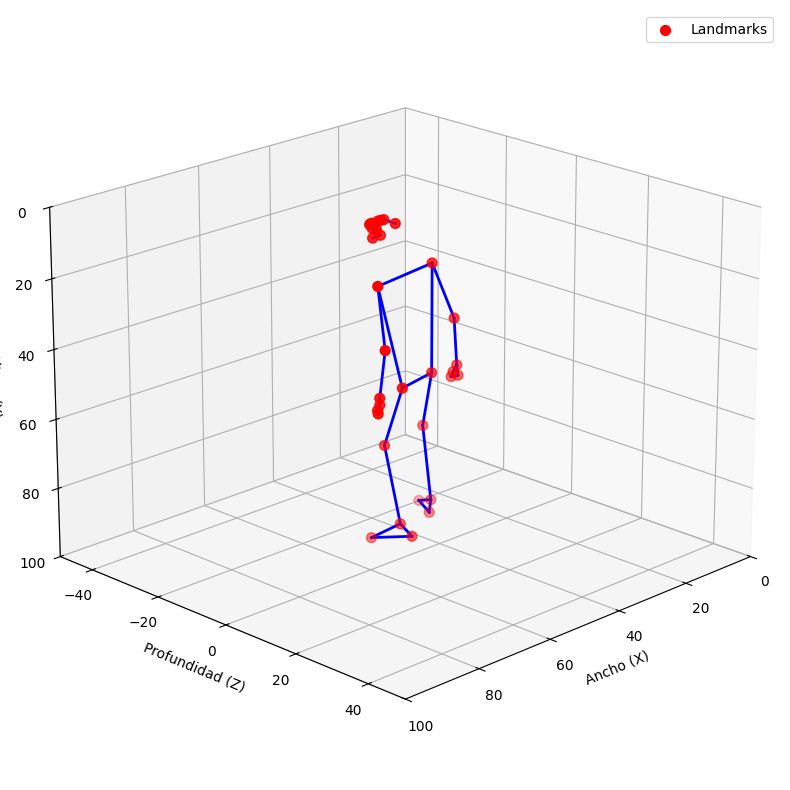

In [21]:
import os
import sys
import cv2, csv
import numpy as np
import pandas as pd
import mediapipe as mp
import warnings, logging
from dataclasses import dataclass

warnings.filterwarnings('ignore')
logging.getLogger('mediapipe').setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Definimos las conexiones de MediaPipe
mp_holistic = mp.solutions.holistic
POSE_CONNECTIONS = mp_holistic.POSE_CONNECTIONS
HAND_CONNECTIONS = mp_holistic.HAND_CONNECTIONS
vistas = {}
pose_3d_final = None

def main():
    # 1. Configuración de rutas (Cambia esto por tus archivos)
    path_frontal = "../datos/MultiViewVisibleThermalImagesHPE/test/00_17/00_17_1680262465720_rgb.png"
    path_derecha = "../datos/MultiViewVisibleThermalImagesHPE/test/00_16/00_16_1680262465720_rgb.png"
    path_izquierda = "../datos/MultiViewVisibleThermalImagesHPE/test/00_15/00_15_1680262465720_rgb.png"

    # 2. Inicializar MediaPipe
    with mp_holistic.Holistic(static_image_mode=True, min_detection_confidence=0.5) as holistic:
        
        # vistas = {}
        rutas = {
            "frontal": path_frontal,
            "derecha": path_derecha,
            "izquierda": path_izquierda
        }

        for nombre, ruta in rutas.items():
            if not os.path.exists(ruta):
                print(f"Error: No se encuentra la imagen en {ruta}")
                continue
            
            # Leer imagen y convertir a RGB
            image = cv2.imread(ruta)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Extraer Landmarks
            raw_lms = get_landmarks_from_image(image_rgb, holistic)
            
            if raw_lms:
                # Normalizar a cuadrícula 100x100 usando tu función original
                vistas[nombre] = normalize_landmarks(raw_lms, tam_target=100, margin=5)
                print(f"✓ Vista {nombre} procesada correctamente.")
            else:
                print(f"× No se detectaron puntos en la vista {nombre}.")

        # 3. Verificar que tenemos las vistas necesarias para la reconstrucción
        if "frontal" in vistas and ("derecha" in vistas or "izquierda" in vistas):
            
            # Obtener diccionarios (pueden estar vacíos si falló la detección)
            lms_f = vistas.get("frontal", {})
            lms_r = vistas.get("derecha", {})
            lms_l = vistas.get("izquierda", {})

            print(lms_f)
            print(lms_r)
            print(lms_l)
            
            # 4. Reconstrucción 3D
            pose_3d_final = reconstruct_3d_pose(lms_f, lms_r, lms_l)
            print(pose_3d_final)
            
            # 5. Visualización
            print("Generando visualización 3D...")
            plot_3d_pose(pose_3d_final)
            
            # Opcional: Guardar a CSV
            # save_landmarks_to_csv(lms_f, "resultado_frontal.csv")
        else:
            print("Error: Se requiere al menos la vista frontal y una lateral.")


if __name__ == "__main__":
    main()

TypeError: 'NoneType' object is not iterable

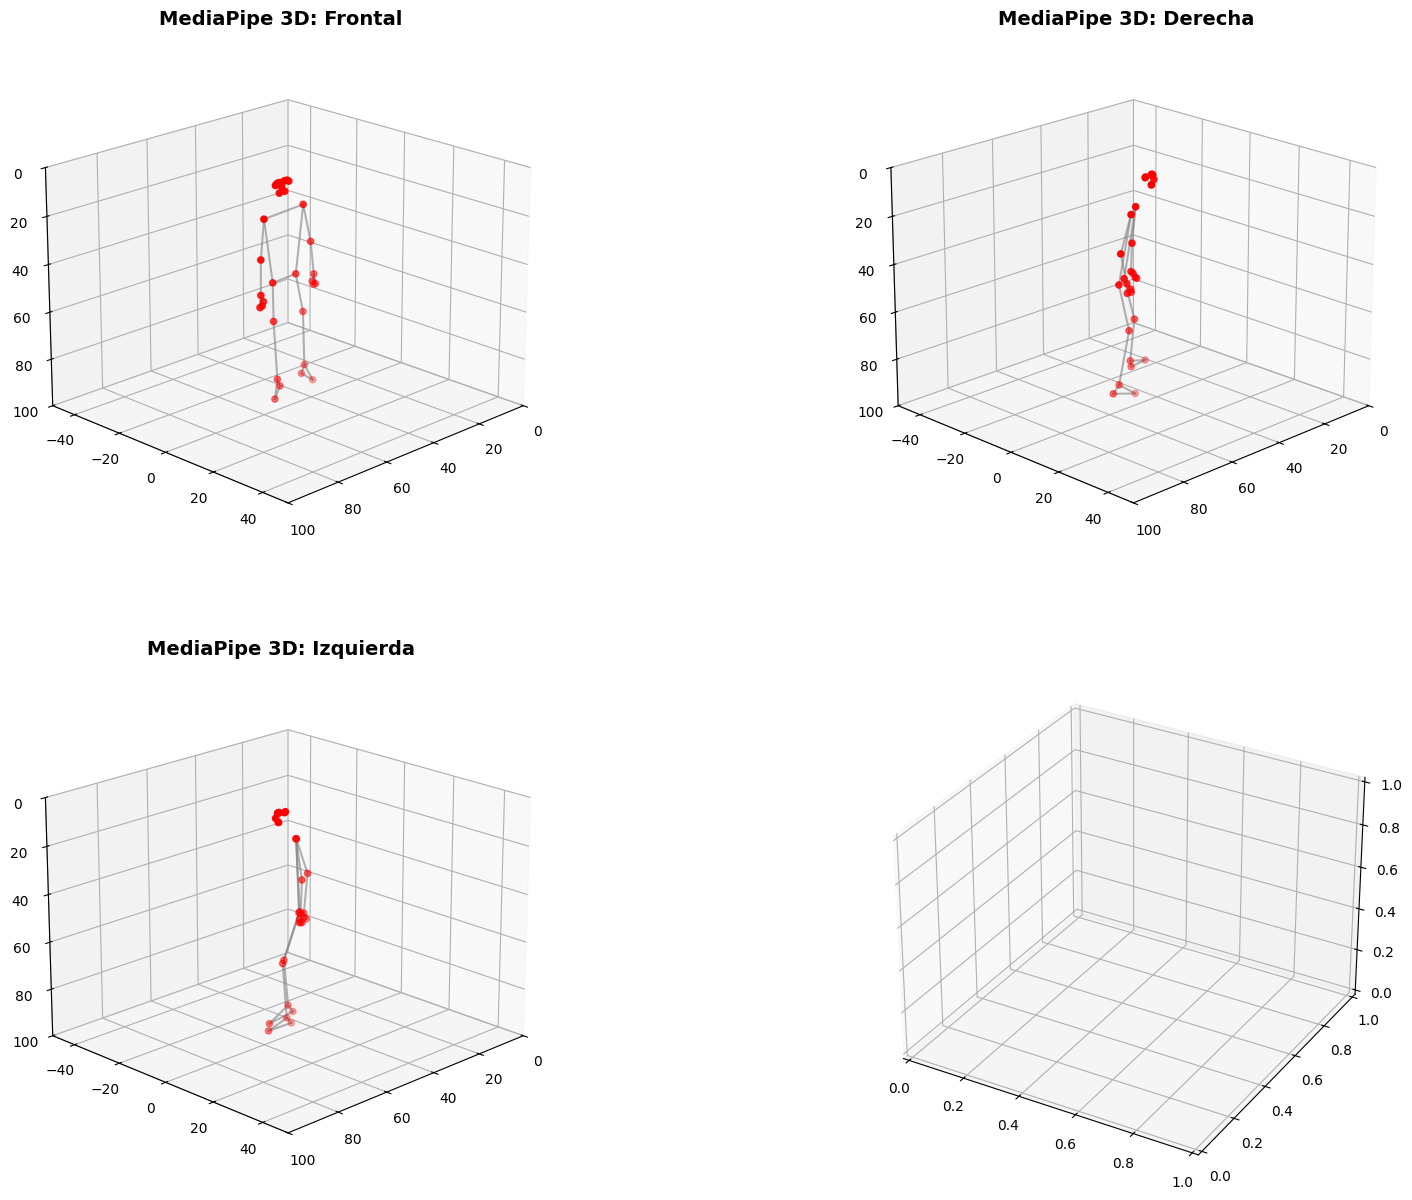

In [22]:
import matplotlib.pyplot as plt

def plot_comparativo_4_poses(vistas_2d, pose_reconstruida_3d):
    fig = plt.figure(figsize=(20, 15))
    titulos = ["MediaPipe 3D: Frontal", "MediaPipe 3D: Derecha", "MediaPipe 3D: Izquierda", "NUESTRA RECONSTRUCCIÓN 3D"]
    
    # Definir qué vistas vamos a iterar (las 3 originales + la nuestra)
    vistas_nombres = ["frontal", "derecha", "izquierda"]
    
    for i in range(4):
        ax = fig.add_subplot(2, 2, i+1, projection='3d')
        
        if i < 3:
            # Poses estimadas por MediaPipe individualmente
            nombre = vistas_nombres[i]
            if nombre not in vistas_2d: continue
            
            puntos = vistas_2d[nombre]["pose"]
            # En MP individual, usamos sus x, y, z internos
            xs = [p.x for p in puntos]
            ys = [p.z for p in puntos] # MediaPipe usa Z para profundidad interna
            zs = [p.y for p in puntos]
            lm_dict = {p.landmark_id: (p.x, p.y, p.z) for p in puntos}
            color_linea = 'gray'
        else:
            # Nuestra pose reconstruida
            xs = [p.x for p in pose_reconstruida_3d]
            ys = [p.z for p in pose_reconstruida_3d]
            zs = [p.y for p in pose_reconstruida_3d]
            lm_dict = {p.id: (p.x, p.y, p.z) for p in pose_reconstruida_3d}
            color_linea = 'blue'

        # Dibujar puntos
        ax.scatter(xs, ys, zs, c='red', s=20)

        # Dibujar conexiones
        for connection in mp_holistic.POSE_CONNECTIONS:
            start_id, end_id = connection
            if start_id in lm_dict and end_id in lm_dict:
                p1, p2 = lm_dict[start_id], lm_dict[end_id]
                # Ajuste de ejes para visualización (x, z_interno, y_altura)
                if i < 3:
                    ax.plot([p1[0], p2[0]], [p1[2], p2[2]], [p1[1], p2[1]], c=color_linea, alpha=0.6)
                else:
                    ax.plot([p1[0], p2[0]], [p1[2], p2[2]], [p1[1], p2[1]], c=color_linea, linewidth=2)

        # Configuración de cámara y límites
        ax.set_title(titulos[i], fontsize=14, fontweight='bold')
        ax.set_xlim(0, 100)
        ax.set_ylim(-50, 50)
        ax.set_zlim(100, 0)
        ax.view_init(elev=20, azim=45)

    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN EN LA CELDA ---
# Asumiendo que 'vistas' tiene los datos normalizados y 'pose_3d_final' es el resultado
plot_comparativo_4_poses(vistas, pose_3d_final)